# Rest-Frame Properties, Diagnostics, and Batch Processing

tengri computes derived galaxy properties — M★, SFR, sSFR, D4000, UV slope
— as differentiable functions of the model parameters. This notebook shows
how to extract and batch-process them.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("specialist", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, convergence_table, plot_sfh, setup_style

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

spec = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, observation=obs)

W0405 03:53:35.187874 36383936 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_88936/4270104764.py:21: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, observation=obs)


<local>/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


In [3]:
# Fit a single galaxy
key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(0.3)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=key)

fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="spectroscopy")
_ = fitter.run("map", n_steps=500, verbose=False)
t0_c = time.perf_counter()
fitter.compile(verbose=False)
t_compile = time.perf_counter() - t0_c
t0 = time.perf_counter()
result = fitter.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    verbose=False,
)
t_run = time.perf_counter() - t0
print(f"XLA compile: {t_compile:.1f}s (one-time, cached)")
print(f"native_geovi: {t_run:.1f}s <- runtime per galaxy")
print(f"Samples: {len(next(iter(result.samples.values())))}")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 03:53:39.867596 36383805 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 03:53:41.609630 36383805 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0405 03:53:56.673607 36383805 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 03:54:11.939800 36383805 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


<local>/Projects/diffsed/src/tengri/inference/fitter.py:764: UserWarning: Seeds disagree: H = 143.6 ± 58.3 (CV=41%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


W0405 03:54:21.634009 36383805 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


XLA compile: 18.4s (one-time, cached)
native_geovi: 42.3s <- runtime per galaxy
Samples: 2000


In [4]:
convergence_table({"vi": result})

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
vi                  1442     1531      1.4        —        —         OK


{'vi': {'ess_min': 1441.8434001404987,
  'ess_median': 1531.0706682399896,
  'n_params_low_ess': 0,
  'tau_max_max': 1.3871131912141863,
  'tau_max_median': 1.306284953010568,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []}}

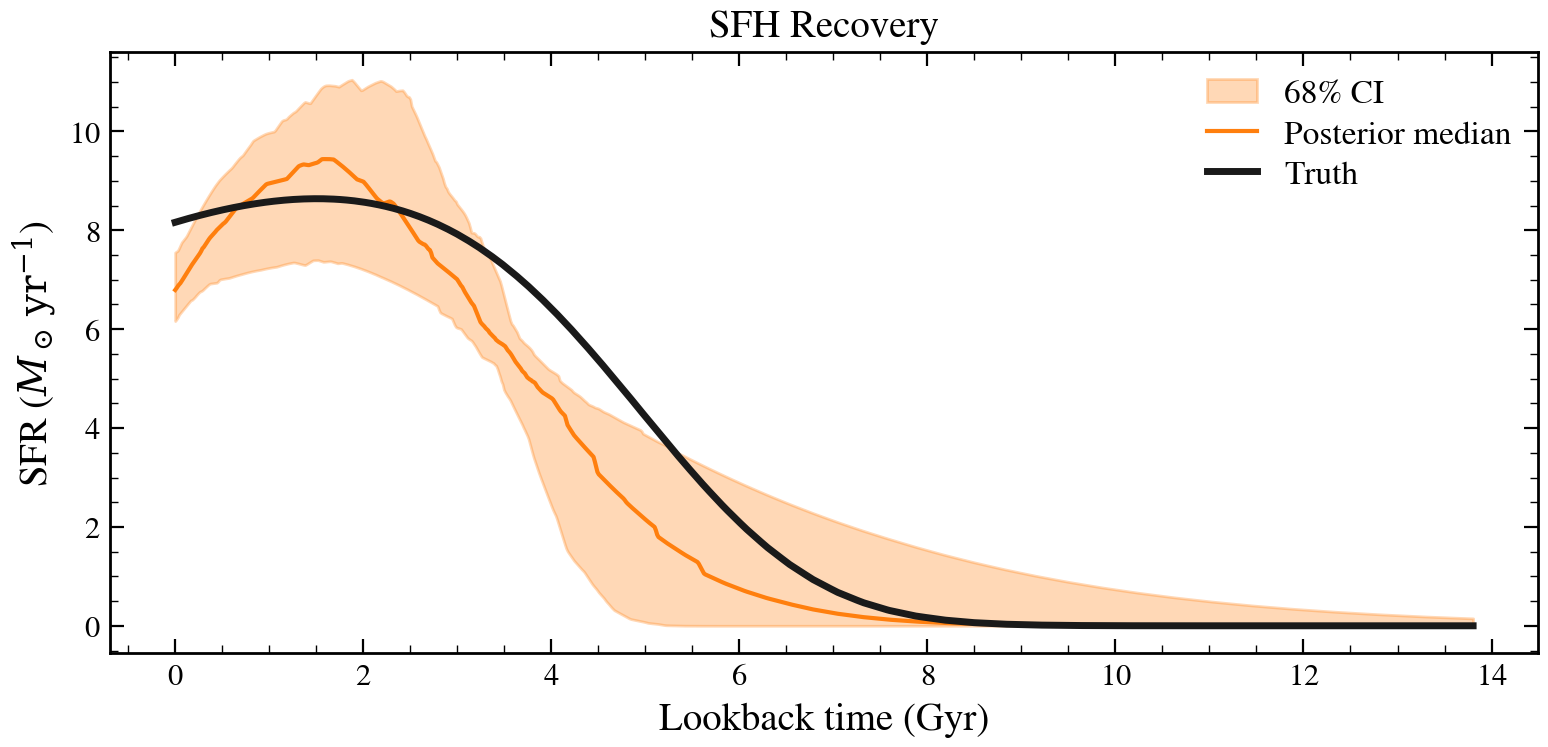

In [5]:
# --- SFH recovery figure ---
sfh_true = model.predict_sfh(true_params)
t_gyr = np.array(sfh_true["t_gyr"])
sfr_key = "sfr_full" if model.spec.stochastic else "sfr_mean"
sfr_true = np.array(sfh_true[sfr_key])

n_samp = min(50, len(next(iter(result.samples.values()))))
sfh_draws = []
for i in range(n_samp):
    s_i = {k: result.samples[k][i] for k in result.samples}
    sfh_draws.append(np.array(model.predict_sfh(s_i)[sfr_key]))
sfh_arr = np.array(sfh_draws)
lo, hi = np.percentile(sfh_arr, [16, 84], axis=0)
median_sfh = np.median(sfh_arr, axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(t_gyr, lo, hi, color=COLORS["geovi"], alpha=0.3, label="68% CI")
ax.plot(t_gyr, median_sfh, color=COLORS["geovi"], lw=1.5, label="Posterior median")
ax.plot(t_gyr, sfr_true, color=COLORS["truth"], lw=2.5, label="Truth")
ax.set_xlabel("Lookback time (Gyr)")
ax.set_ylabel(r"SFR ($M_\odot\,{\rm yr}^{-1}$)")
ax.legend()
ax.set_title("SFH Recovery")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig00_sfh_recovery.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Derived quantities from posterior
sfh_derived = []
for i in range(min(500, len(next(iter(result.samples.values()))))):
    p = {k: v[i] for k, v in result.samples.items()}
    sfh_i = model.predict_sfh(p)
    sfr = np.array(sfh_i["sfr_mean"])
    t = np.array(sfh_i["t_gyr"])
    # Compute stellar mass (integral of SFR)
    dt = np.diff(t * 1e9)
    m_star = np.sum(sfr[:-1] * np.abs(dt))
    # SFR at 100 Myr
    idx_100 = np.argmin(np.abs(t - 0.1))
    sfr_100 = sfr[idx_100]
    sfh_derived.append(
        {"m_star": m_star, "sfr_100": sfr_100, "ssfr": sfr_100 / max(m_star, 1e-10)}
    )

m_star_arr = np.array([d["m_star"] for d in sfh_derived])
sfr_100_arr = np.array([d["sfr_100"] for d in sfh_derived])
ssfr_arr = np.array([d["ssfr"] for d in sfh_derived])

In [7]:
# Compute true derived quantities for overlay
sfh_true_d = model.predict_sfh(true_params)
sfr_true_d = np.array(sfh_true_d["sfr_mean"])
t_true_d = np.array(sfh_true_d["t_gyr"])
dt_true = np.diff(t_true_d * 1e9)
m_star_true = np.sum(sfr_true_d[:-1] * np.abs(dt_true))
idx_100_true = np.argmin(np.abs(t_true_d - 0.1))
sfr_100_true = sfr_true_d[idx_100_true]
ssfr_true = sfr_100_true / max(m_star_true, 1e-10)

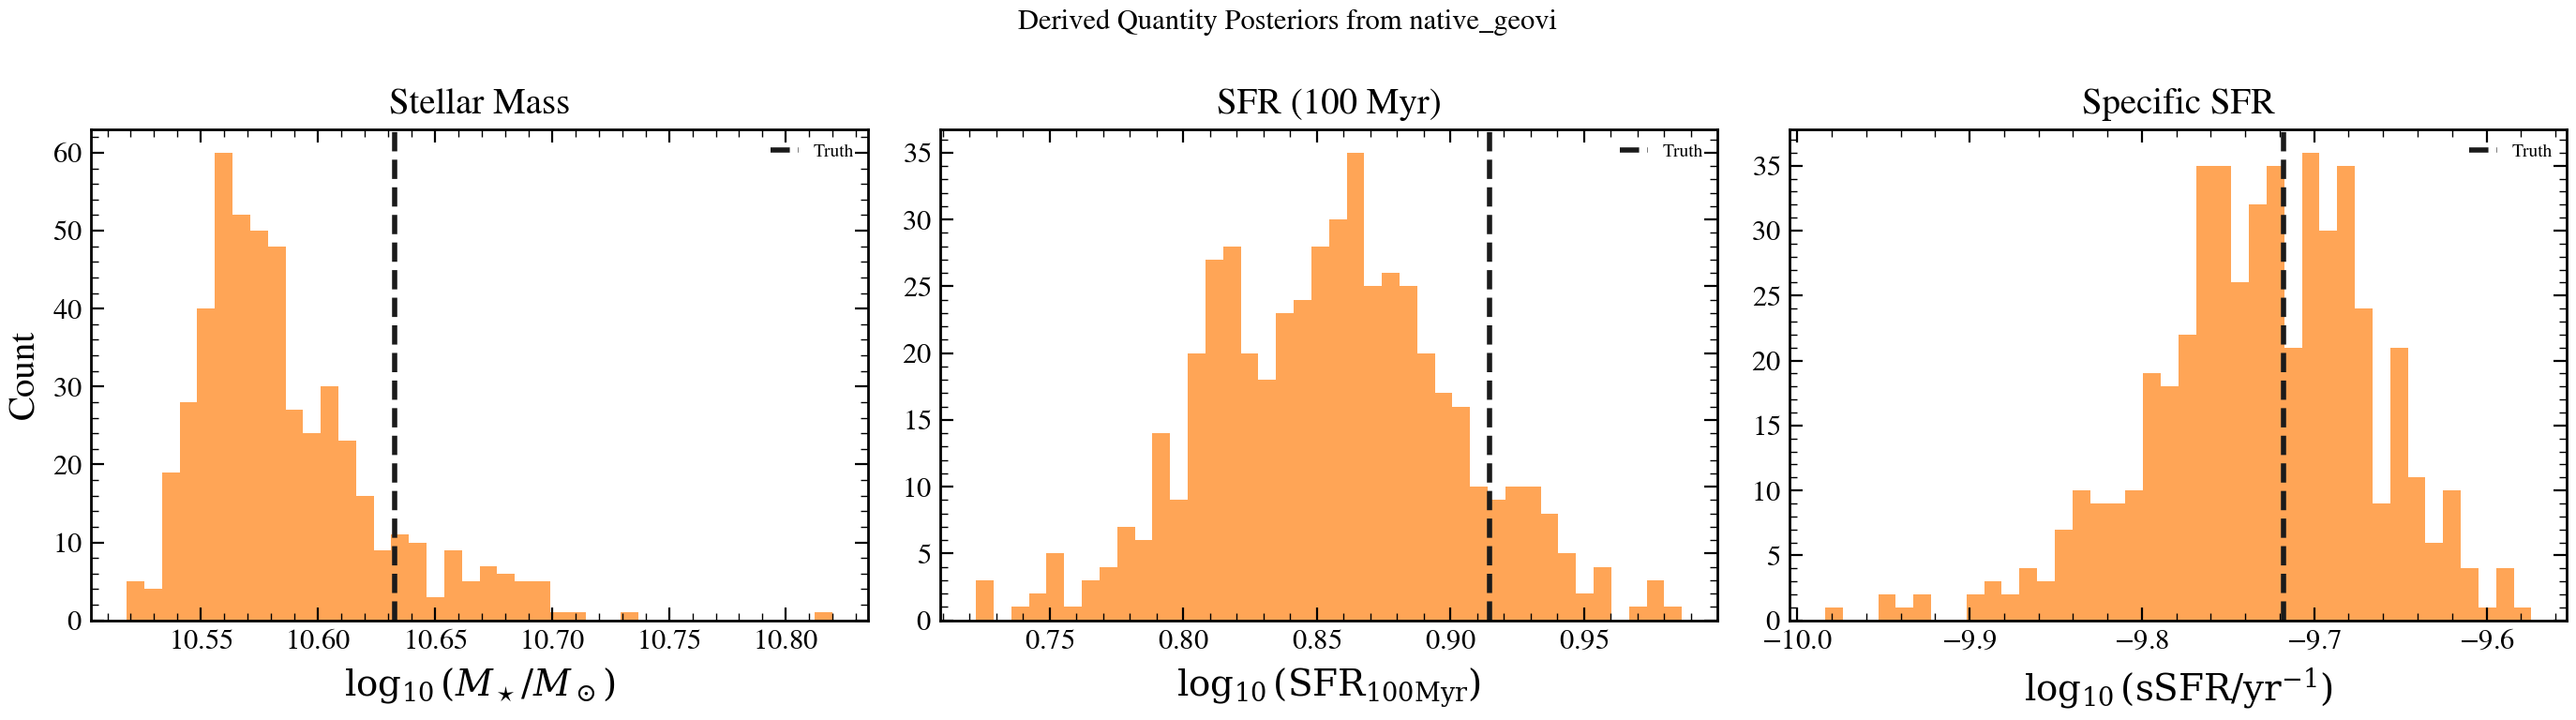

In [8]:
# --- FIGURE 1: Derived quantity posteriors (histograms) with truth ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

ax1.hist(np.log10(np.clip(m_star_arr, 1, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax1.axvline(np.log10(max(m_star_true, 1)), color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax1.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax1.set_ylabel("Count")
ax1.set_title("Stellar Mass")
ax1.legend(fontsize=7)

ax2.hist(np.log10(np.clip(sfr_100_arr, 1e-5, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax2.axvline(np.log10(max(sfr_100_true, 1e-5)), color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax2.set_xlabel(r"$\log_{10}({\rm SFR}_{100\rm Myr})$")
ax2.set_title("SFR (100 Myr)")
ax2.legend(fontsize=7)

ax3.hist(np.log10(np.clip(ssfr_arr, 1e-15, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax3.axvline(np.log10(max(ssfr_true, 1e-15)), color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax3.set_xlabel(r"$\log_{10}({\rm sSFR} / {\rm yr}^{-1})$")
ax3.set_title("Specific SFR")
ax3.legend(fontsize=7)

fig.suptitle("Derived Quantity Posteriors from native_geovi", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_derived_posteriors.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Batch: 100 galaxies from prior, compute derived
N_BATCH = 100
batch_keys = jax.random.split(jax.random.PRNGKey(0), N_BATCH)
batch_params = jax.vmap(spec.sample)(batch_keys)

batch_sfh = []
t0 = time.perf_counter()
for i in range(N_BATCH):
    p = {k: v[i] for k, v in batch_params.items()}
    sfh_i = model.predict_sfh(p)
    batch_sfh.append(sfh_i)
t_batch = time.perf_counter() - t0
print(f"SFH for {N_BATCH} galaxies: {t_batch:.2f}s ({t_batch / N_BATCH * 1e3:.1f} ms/galaxy)")

SFH for 100 galaxies: 0.18s (1.8 ms/galaxy)


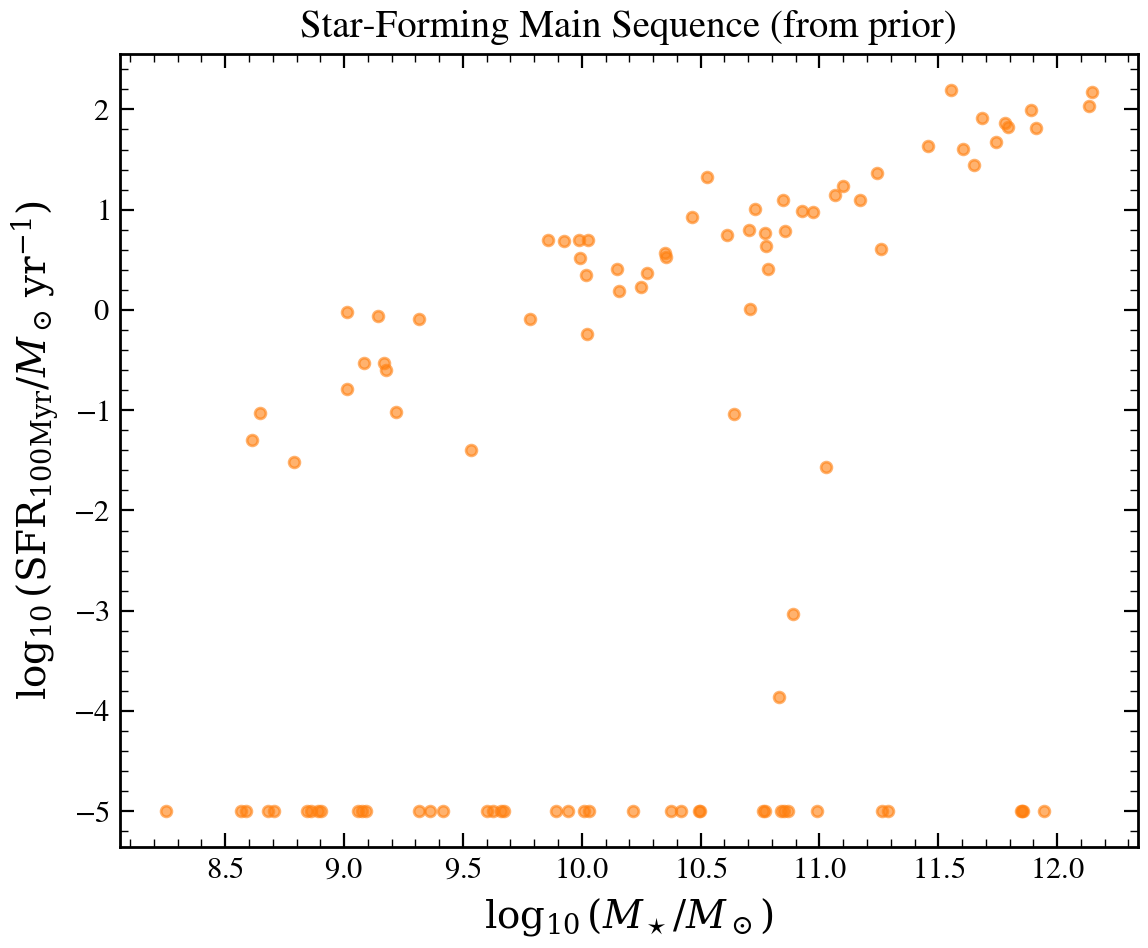

In [10]:
# --- FIGURE 3: M★ vs SFR (main sequence from prior) ---
batch_mstar = []
batch_sfr = []
for sfh_i in batch_sfh:
    sfr = np.array(sfh_i["sfr_mean"])
    t = np.array(sfh_i["t_gyr"])
    dt = np.diff(t * 1e9)
    ms = np.sum(sfr[:-1] * np.abs(dt))
    idx_100 = np.argmin(np.abs(t - 0.1))
    batch_mstar.append(ms)
    batch_sfr.append(sfr[idx_100])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    np.log10(np.clip(batch_mstar, 1, None)),
    np.log10(np.clip(batch_sfr, 1e-5, None)),
    s=15,
    alpha=0.6,
    color=COLORS["geovi"],
)
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax.set_ylabel(r"$\log_{10}({\rm SFR}_{100\rm Myr} / M_\odot\,{\rm yr}^{-1})$")
ax.set_title("Star-Forming Main Sequence (from prior)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_main_sequence.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Scaling test
for n in [10, 50, 100, 500]:
    keys_n = jax.random.split(jax.random.PRNGKey(0), n)
    params_n = jax.vmap(spec.sample)(keys_n)
    batch_phot = jax.jit(jax.vmap(model.predict_photometry))
    _ = batch_phot(params_n)
    _.block_until_ready()
    t0 = time.perf_counter()
    for _ in range(20):
        r = batch_phot(params_n)
        r.block_until_ready()
    t = (time.perf_counter() - t0) / 20 * 1e3
    print(f"  vmap({n:>4d}): {t:.1f} ms  ({t / n * 1e3:.1f} µs/galaxy)")

  vmap(  10): 0.1 ms  (12.7 µs/galaxy)


  vmap(  50): 0.3 ms  (5.5 µs/galaxy)
  vmap( 100): 0.5 ms  (5.2 µs/galaxy)


  vmap( 500): 1.6 ms  (3.2 µs/galaxy)


## Summary

- Derived quantities (M★, SFR, sSFR) computed from the same posterior samples.
- Batch processing via vmap: sublinear scaling from XLA parallelism.
- All quantities are differentiable — can be used in gradient-based objectives.